In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

In [2]:
df=pd.read_csv("SalaryGrowth.csv")
df

,Years of Experience,Number of Projects,Salary
0,1,1,25000
1,2,2,30000
2,3,2,35000
3,4,3,45000
4,5,3,50000
5,6,4,60000
6,7,4,65000
7,8,5,75000
8,9,5,80000
9,10,6,90000


In [3]:
df.dtypes

Years of Experience    int64
Number of Projects     int64
Salary                 int64
dtype: object

In [4]:
df.isnull().sum()

Years of Experience    0
Number of Projects     0
Salary                 0
dtype: int64

In [5]:
y=df[['Salary']]
x=df[['Years of Experience','Number of Projects']]

In [6]:
x_train,x_test,y_train,y_test=train_test_split(x,y,train_size=0.7,random_state=42)

In [7]:
model=LinearRegression()
model.fit(x_train,y_train)
y_pred_line=model.predict(x_test)
y_pred_line

array([[79310.34482759],
       [32068.96551724],
       [60517.24137931]])

In [8]:
degree =2
poly =PolynomialFeatures(degree=degree)
x_train_poly=poly.fit_transform(x_train)
x_test_poly=poly.fit_transform(x_test)

model_poly=LinearRegression()
model_poly.fit(x_train_poly,y_train)
y_pred_poly=model_poly.predict(x_test_poly)
y_pred_poly

array([[81304.34782609],
       [33260.86956522],
       [58913.04347826]])

In [9]:
Linear_MSE=mean_squared_error(y_test,y_pred_line)

In [10]:
Polynomial_MSE=mean_squared_error(y_test,y_pred_poly)

In [11]:
if Linear_MSE < Polynomial_MSE:
    print("Linear Model is better")
else:
    print("Polynomial Model in better")

Linear Model is better


# KNN

In [13]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

In [15]:
df=pd.read_csv("Social_Network_Ads.csv")
df

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0
...,...,...,...,...,...
395,15691863,Female,46,41000,1
396,15706071,Male,51,23000,1
397,15654296,Female,50,20000,1
398,15755018,Male,36,33000,0


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   User ID          400 non-null    int64 
 1   Gender           400 non-null    object
 2   Age              400 non-null    int64 
 3   EstimatedSalary  400 non-null    int64 
 4   Purchased        400 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 15.8+ KB


In [17]:
df['Gender'].unique()

array(['Male', 'Female'], dtype=object)

In [18]:
df['Purchased'].unique()

array([0, 1])

In [20]:
df=pd.get_dummies(df,drop_first=True,)

In [23]:
y=df[['Purchased']]
x=df.drop(["Purchased","User ID"],axis=1)

In [24]:
x.head()

,Age,EstimatedSalary,Gender_Male
0,19,19000,True
1,35,20000,True
2,26,43000,False
3,27,57000,False
4,19,76000,True


In [25]:
y.head()

,Purchased
0,0
1,0
2,0
3,0
4,0


In [30]:
#test_size=20%
# random_ state=70
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=70)

In [31]:
KNN=KNeighborsClassifier(n_neighbors=3)
KNN.fit(x_train,y_train)

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\neighbors\_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


,n_neighbors,3
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [32]:
y_pred=KNN.predict(x_test)
y_pred

array([1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1,
       0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0,
       0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0])

In [35]:
prediction=pd.DataFrame({
    'actual':y_test.squeeze(),
    'predicated':y_pred.squeeze()
})
prediction

,actual,predicated
283,1,1
74,0,0
292,1,1
150,0,0
311,1,1
...,...,...
112,0,0
38,0,0
302,1,1
65,0,0


In [36]:
# age :25 ,salary:30000 ,Gender:female
# y_new ==0 lachie to not purchesed save and 1 apie to purchesed
x_new=[[25,30000,False]]
y_new=KNN.predict(x_new)
if y_new==1:
    print("purchess")
else:
    print("not purchess")

purchess


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


In [40]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [41]:
conf_matrix=confusion_matrix(y_test,y_pred)
conf_matrix

array([[45, 11],
       [ 3, 21]])

Text(50.722222222222214, 0.5, 'Actual')

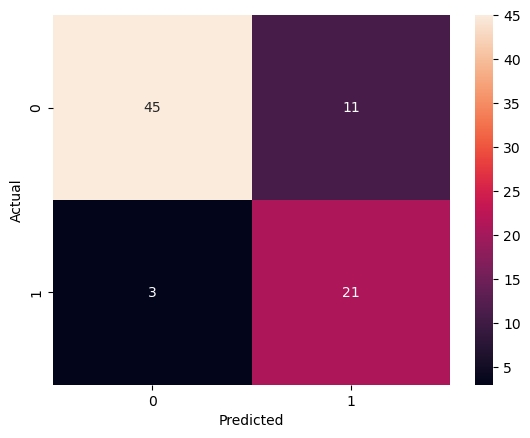

In [42]:
sns.heatmap(conf_matrix,annot=True)
plt.xlabel("Predicted")
plt.ylabel("Actual")

In [43]:
TN=conf_matrix[0,0]
TP=conf_matrix[1,1]
FN=conf_matrix[1,0]
FP=conf_matrix[0,1]
TN,TP,FN,FP

(np.int64(45), np.int64(21), np.int64(3), np.int64(11))

In [44]:
accuracy=(TP+TN)/(TP+TN+FP+FN)
accuracy

np.float64(0.825)

In [45]:
precision=TP/(TP+FP)
precision

np.float64(0.65625)